# A Baker's Dozen

Twelve solved examples from the Symbulator 9 documentation, and a bonus. Each of these circuits looks like an afternoon's work by hand. Symbulator solves each one in a single run, or in two when a switch splits the problem into intervals, and no two of them make the same point.

This is the notebook of the booklet at https://learn.symbulator.com/dozen.pdf. Every description below is the one in the app's built-in examples, read from the app's own file and not retyped, and each run is the `symbulator` call that solves it. Under each run the answers the booklet prints are shown, to read beside what the cell computes. Where the booklet shows a rounded decimal the cell shows the exact value, and `rounded()` or `polar()` gives the same digits.

1. **AS7's Example 3.4** — Supernodes around a dependent source
2. **NR12's Example 5.7** — A realistic op amp model
3. **Bo2's Example 3.3** — Two op amps, every conductance a symbol
4. **AS7's Problem 9.73** — Eight impedances that will not reduce
5. **AS7's Example 10.14** — Phasors with a dependent source
6. **AS7's Example 12.11** — Three-phase wye-delta with line impedances
7. **AS7's Practice Problem 13.13** — Coupled coils in a tangle
8. **NR11's switched RLC with coupled coils** — A transient across a coupling
9. **Bo2's Drill Exercise 6.6** — Two capacitors around an op amp
10. **Prof. Boulet's exam problem** — The switch, the ladder and the damped sine
11. **AS7's Problem 19.2** — A two-port with no ground
12. **NR12's Example 18.6** — Two amplifiers known only by their h parameters

★ **A freebie, on the house** — One dependent source of each kind

If you are on Colab, run the first cell.

In [1]:
# On Google Colab the package is not installed yet; install it there.
# A local Jupyter already has it: pip install symbulator[notebook]
import sys
if "google.colab" in sys.modules:
    %pip install -q symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.17'

## Sample 1 of 12: AS7's Example 3.4

**Supernodes around a dependent source**

*Alexander & Sadiku sampler*

Find the node voltages in the circuit of the figure.

![The circuit of AS7's Example 3.4](https://learn.symbulator.com/assets/circuit/as7-ex3-4.jpg)

**Why it is here.** Two voltage sources float between non-reference nodes, and one of them is worth three times the drop across a resistor. By hand that is two supernodes and a constraint equation. Here it is eight lines typed as they are drawn.

*Analysis: DC. Rounding: approx.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=as7&entry=2)

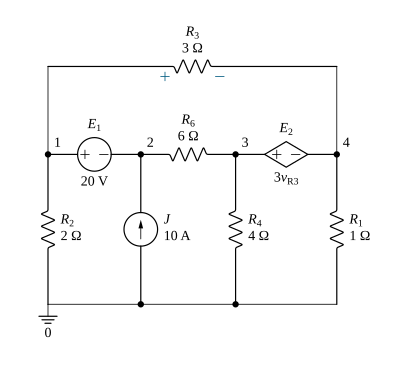

In [3]:
c1 = '''
e1,1,2,20
r3,1,4,3
r6,2,3,6
e2,3,4,3*vr3
r2,1,0,2
j,0,2,10
r4,3,0,4
r1,4,0,1
'''
draw(c1)

In [4]:
r1 = dc(c1)
r1

Result(domain='dc')
  i_e1 = -340/9
  i_e2 = -640/9
  i_j = 10
  i_r1 = -140/3
  i_r2 = 40/3
  i_r3 = 220/9
  i_r4 = 130/3
  i_r6 = -250/9
  p_e1 = -6800/9
  p_e2 = -140800/9
  p_j = -200/3
  p_r1 = 19600/9
  p_r2 = 3200/9
  p_r3 = 48400/27
  p_r4 = 67600/9
  p_r6 = 125000/27
  r_e1 = 9/17
  r_e2 = 99/32
  r_j = 2/3
  v_1 = 80/3
  v_2 = 20/3
  v_3 = 520/3
  v_4 = -140/3
  v_e1 = 20
  v_e2 = 220
  v_j = -20/3
  v_r1 = -140/3
  v_r2 = 80/3
  v_r3 = 220/3
  v_r4 = 520/3
  v_r6 = -500/3

**The booklet prints**

$$v_{1} = 26.667\ \mathrm{V}$$

$$v_{2} = 6.6667\ \mathrm{V}$$

$$v_{3} = 173.33\ \mathrm{V}$$

$$v_{4} = -46.667\ \mathrm{V}$$

## Sample 2 of 12: NR12's Example 5.7

**A realistic op amp model**

*Nilsson & Riedel sampler*

Analyze the noninverting amplifier using the realistic op amp model, with open-loop gain $A$ = 50,000, input resistance $R_i$ = 100 kΩ and output resistance $R_o$ = 7.5 kΩ. Find the gain $v_o/v_g$.

![The circuit of NR12's Example 5.7](https://learn.symbulator.com/assets/circuit/nr12-ex5-7.jpg)

**Why it is here.** The model is a dependent source with a finite gain, an input resistance and an output resistance, written as three ordinary elements. The source stays a symbol, so the gain is read straight off the answer.

*Analysis: DC. Rounding: approx. Evaluate: v_3/vg.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=nr12&entry=14)

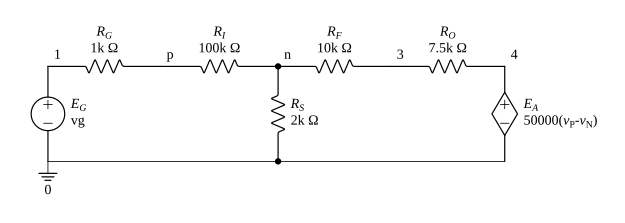

In [5]:
c2 = '''
eg,1,0,vg
rg,1,p,1'k
ri,p,n,100'k
rs,n,0,2'k
rf,n,3,10'k
ro,4,3,7.5'k
ea,4,0,50000*(vp-vn)
'''
draw(c2)

In [6]:
r2 = dc(c2)
r2

Result(domain='dc')
  i_ea = -0.000499899595126157*vg
  i_eg = -1.94960920083569e-9*vg
  i_rf = -0.000499899595126157*vg
  i_rg = 1.94960920083569e-9*vg
  i_ri = 1.94960920083569e-9*vg
  i_ro = 0.000499899595126157*vg
  i_rs = 0.000499901544735358*vg
  p_ea = -0.00487304425075997*vg**2
  p_eg = -1.94960920083569e-9*vg**2
  p_rf = 0.00249899605207296*vg**2
  p_rg = 3.80097603602573e-15*vg**2
  p_ri = 3.80097603598244e-13*vg**2
  p_ro = 0.00187424703905472*vg**2
  p_rs = 0.000499803108857594*vg**2
  r_ea = 19500.0078000031
  r_eg = 512923307.692308
  v_1 = vg
  v_3 = 5.99879904073229*vg
  v_4 = 9.74804600417846*vg
  v_ea = 9.74804600417846*vg
  v_eg = vg
  v_n = 0.999803089470716*vg
  v_p = 0.999998050390799*vg
  v_rf = -4.99899595126157*vg
  v_rg = 1.94960920085752e-6*vg
  v_ri = 0.000194960920083531*vg
  v_ro = 3.74924696344618*vg
  v_rs = 0.999803089470716*vg

In [7]:
evaluate(r2, 'v_3/vg')

5.99879904073229

**The booklet prints**

$$v_{3}/v_{g} = 5.9988$$

## Sample 3 of 12: Bo2's Example 3.3

**Two op amps, every conductance a symbol**

*Course, Lesson 5 (Operational Amplifiers)*

Find $v_o$ in terms of the conductances and the applied voltage $v_S$.

![The circuit of Bo2's Example 3.3](https://learn.symbulator.com/assets/practice/bo2s-example-3-3-cascade-37.jpg)

**Why it is here.** There is not a single number in the circuit. The answer is the gain as a formula, and its shape explains the circuit: a difference of conductances over a difference of conductances.

*Analysis: DC. Rounding: exact.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=5b&entry=14)

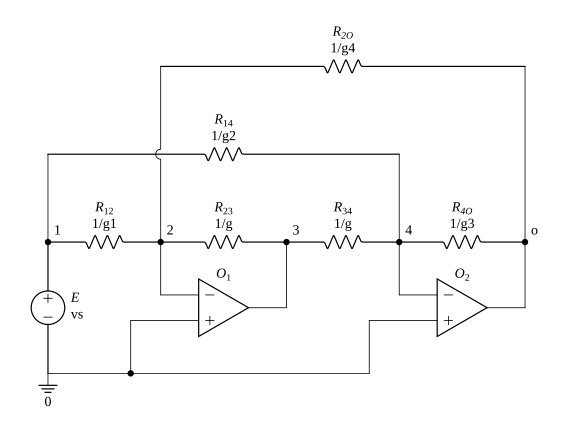

In [8]:
c3 = '''
e,1,0,vs
r12,1,2,1/g1
r14,1,4,1/g2
r4o,4,o,1/g3
r2o,2,o,1/g4
r23,2,3,1/g
r34,3,4,1/g
o1,0,2,3
o2,0,4,o
'''
draw(c3)

In [9]:
r3 = dc(c3)
r3

Result(domain='dc')
  i_e = vs*(-g1 - g2)
  i_o1 = 2*vs*(-g1*g3 + g2*g4)/(g3 - g4)
  i_o2 = vs*(g1*g3 + g1*g4 - g2*g3 - g2*g4)/(g3 - g4)
  i_r12 = g1*vs
  i_r14 = g2*vs
  i_r23 = vs*(g1*g3 - g2*g4)/(g3 - g4)
  i_r2o = g4*vs*(-g1 + g2)/(g3 - g4)
  i_r34 = vs*(-g1*g3 + g2*g4)/(g3 - g4)
  i_r4o = g3*vs*(-g1 + g2)/(g3 - g4)
  p_e = vs**2*(-g1 - g2)
  p_o1 = -2*vs**2*(g1*g3 - g2*g4)**2/(g*(g3 - g4)**2)
  p_o2 = -vs**2*(g1 - g2)*(g1*g3 + g1*g4 - g2*g3 - g2*g4)/(g3 - g4)**2
  p_r12 = g1*vs**2
  p_r14 = g2*vs**2
  p_r23 = vs**2*(g1*g3 - g2*g4)**2/(g*(g3 - g4)**2)
  p_r2o = g4*vs**2*(g1 - g2)**2/(g3 - g4)**2
  p_r34 = vs**2*(g1*g3 - g2*g4)**2/(g*(g3 - g4)**2)
  p_r4o = g3*vs**2*(g1 - g2)**2/(g3 - g4)**2
  r_e = 1/(g1 + g2)
  v_1 = vs
  v_2 = 0
  v_3 = vs*(-g1*g3 + g2*g4)/(g*(g3 - g4))
  v_4 = 0
  v_e = vs
  v_o = vs*(g1 - g2)/(g3 - g4)
  v_r12 = vs
  v_r14 = vs
  v_r23 = vs*(g1*g3 - g2*g4)/(g*(g3 - g4))
  v_r2o = vs*(-g1 + g2)/(g3 - g4)
  v_r34 = vs*(-g1*g3 + g2*g4)/(g*(g3 - g4))
  v_r4o = vs*(

**The booklet prints**

$$v_{o} = \dfrac{(g_{1} - g_{2})\,v_{s}}{g_{3} - g_{4}}$$

## Sample 4 of 12: AS7's Problem 9.73

**Eight impedances that will not reduce**

*Course, Lesson 7 (AC)*

Determine the equivalent impedance for the circuit.

![The circuit of AS7's Problem 9.73](https://learn.symbulator.com/assets/circuit/as7p0973.png)

**Why it is here.** No two of these impedances are in series or in parallel, so by hand the circuit needs a delta-wye transformation. Find equivalent does it in one run.

*Analysis: Find equivalent, Resistance / impedance, between nodes 1 and 0, in AC. ω = 1 (any value gives the same answer, every impedance being in ohms). Rounding: 4 digits.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=7&entry=6)

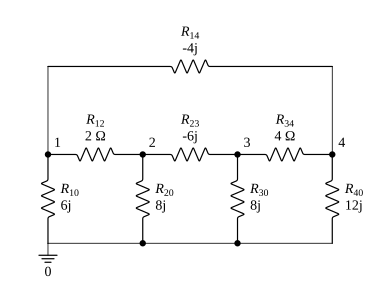

In [10]:
c4 = '''
r10,1,0,6j
r20,2,0,8j
r30,3,0,8j
r40,4,0,12j
r12,1,2,2
r23,2,3,-6j
r34,3,4,4
r14,1,4,-4j
'''
draw(c4)

In [11]:
r4 = er(c4, '1', '0', domain='ac', omega=1)
r4

58950/155357 + 226794*I/155357

**The booklet prints**

$$Z_{eq} = 0.3794 + 1.46\,\mathrm{j}\ \Omega$$

## Sample 5 of 12: AS7's Example 10.14

**Phasors with a dependent source**

*Course, Lesson 7 (AC)*

Find $V_1$ and $V_2$ in the circuit.

![The circuit of AS7's Example 10.14](https://learn.symbulator.com/assets/circuit/as7e1014.png)

**Why it is here.** Nine elements, three sources, one of them controlled by the voltage across a capacitor, and complex impedances on every branch. Nodal analysis by hand means complex algebra in two unknowns.

*Analysis: AC, ω = 1 (any value gives the same answer, every impedance being in ohms). Rounding: 4 digits. Show AC answers as polar phasors.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=7&entry=10)

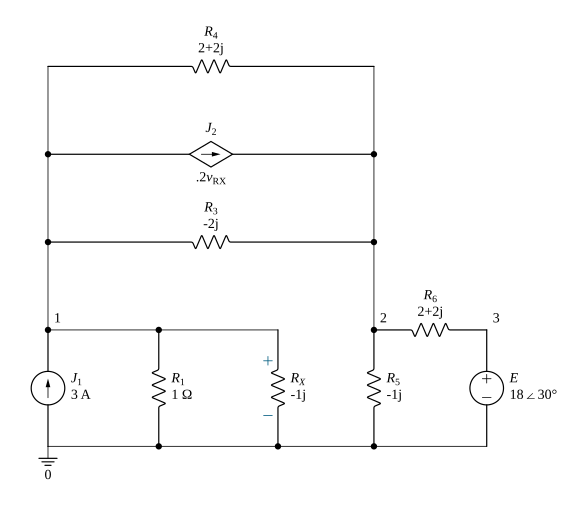

In [12]:
c5 = '''
j1,0,1,3
r1,1,0,1
rx,1,0,-1j
r3,1,2,-2j
j2,1,2,.2*vrx
r4,1,2,2+2j
r5,2,0,-1j
r6,2,3,2+2j
e,3,0,(18∠30°)
'''
draw(c5)

In [13]:
r5 = ac(c5, omega=1)
r5.rounded(4)

Result(domain='ac')
  ap_e = -60.55
  ap_j1 = -2.229
  ap_j2 = -0.9776
  ap_r1 = 3.668
  ap_r3 = 0
  ap_r4 = 2.615
  ap_r5 = 0
  ap_r6 = 57.48
  ap_rx = 0
  i_e = -7.574 - 0.338*I
  i_j1 = 3
  i_j2 = 0.2971 - 0.4529*I
  i_r1 = 1.486 - 2.265*I
  i_r3 = -2.279 + 0.1844*I
  i_r4 = 1.232 + 1.047*I
  i_r5 = 6.823 + 1.117*I
  i_r6 = -7.574 - 0.338*I
  i_rx = 2.265 + 1.486*I
  p_e = -60.55
  p_j1 = -2.229
  p_j2 = -0.9776
  p_r1 = 3.668
  p_r3 = 0
  p_r4 = 2.615
  p_r5 = 0
  p_r6 = 57.48
  p_rx = 0
  q_e = -31.45
  q_j1 = 3.397
  q_j2 = 0.7608
  q_r1 = 0
  q_r3 = -5.230
  q_r4 = 2.615
  q_r5 = -23.90
  q_r6 = 57.48
  q_rx = -3.668
  s_e = -60.55 - 31.45*I
  s_j1 = -2.229 + 3.397*I
  s_j2 = -0.9776 + 0.7608*I
  s_r1 = 3.668
  s_r3 = -5.23*I
  s_r4 = 2.615 + 2.615*I
  s_r5 = -23.9*I
  s_r6 = 57.48 + 57.48*I
  s_rx = -3.668*I
  v_1 = 1.486 - 2.265*I
  v_2 = 1.117 - 6.823*I
  v_3 = 15.59 + 9.0*I
  v_e = 15.59 + 9.0*I
  v_j1 = -1.486 + 2.265*I
  v_j2 = 0.3688 + 4.559*I
  v_r1 = 1.486 - 2.265*I
  v

In [14]:
{'v1': polar(r5['v1']), 'v2': polar(r5['v2'])}

{'v1': 2.708∠-56.73°, 'v2': 6.914∠-80.70°}

**The booklet prints**

$$V_{1} = 2.708\angle{-56.73^\circ}\ \mathrm{V}$$

$$V_{2} = 6.914\angle{-80.70^\circ}\ \mathrm{V}$$

## Sample 6 of 12: AS7's Example 12.11

**Three-phase wye-delta with line impedances**

*Course, Lesson 9 (Three-Phase)*

For the balanced Y-Δ circuit, find the line current $I_{aA}$, the phase voltage $V_{AB}$ and the phase current $I_{AC}$. The source frequency is 60 Hz.

![The circuit of AS7's Example 12.11](https://learn.symbulator.com/assets/circuit/as7e1211.png)

**Why it is here.** The textbook converts the delta to a wye and works a single-phase equivalent. Symbulator needs neither: the three sources, the three lines and the delta go in as drawn.

*Analysis: AC, ω = 120π (60 Hz). Rounding: 4 digits. Polar phasors. Evaluate: vna2-vnb2.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=9&entry=6)

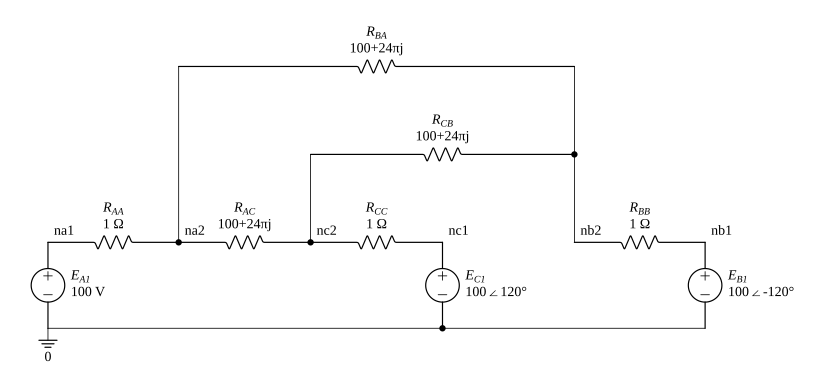

In [15]:
c6 = '''
ea1,na1,0,100
eb1,nb1,0,(100∠-120°)
ec1,nc1,0,(100∠120°)
raa,na1,na2,1
rbb,nb1,nb2,1
rcc,nc1,nc2,1
rac,na2,nc2,100+24*pi*j
rcb,nc2,nb2,100+24*pi*j
rba,nb2,na2,100+24*pi*j
'''
draw(c6)

In [16]:
r6 = ac(c6, omega='120*pi')
r6.rounded(4)

Result(domain='ac')
  ap_ea1 = -94.82
  ap_eb1 = -94.82
  ap_ec1 = -94.82
  ap_raa = 2.762
  ap_rac = 92.06
  ap_rba = 92.06
  ap_rbb = 2.762
  ap_rcb = 92.06
  ap_rcc = 2.762
  i_ea1 = -1.896 + 1.388*I
  i_eb1 = 2.15 + 0.9482*I
  i_ec1 = -0.254 - 2.336*I
  i_raa = 1.896 - 1.388*I
  i_rac = 0.5475 - 1.242*I
  i_rba = -1.349 + 0.1467*I
  i_rbb = -2.15 - 0.9482*I
  i_rcb = 0.8015 + 1.095*I
  i_rcc = 0.254 + 2.336*I
  p_ea1 = -94.82
  p_eb1 = -94.82
  p_ec1 = -94.82
  p_raa = 2.762
  p_rac = 92.06
  p_rba = 92.06
  p_rbb = 2.762
  p_rcb = 92.06
  p_rcc = 2.762
  q_ea1 = -69.41
  q_eb1 = -69.41
  q_ec1 = -69.41
  q_raa = 0
  q_rac = 69.41
  q_rba = 69.41
  q_rbb = 0
  q_rcb = 69.41
  q_rcc = 0
  s_ea1 = -94.82 - 69.41*I
  s_eb1 = -94.82 - 69.41*I
  s_ec1 = -94.82 - 69.41*I
  s_raa = 2.762
  s_rac = 92.06 + 69.41*I
  s_rba = 92.06 + 69.41*I
  s_rbb = 2.762
  s_rcb = 92.06 + 69.41*I
  s_rcc = 2.762
  v_ea1 = 100.0
  v_eb1 = -50.0 - 86.6*I
  v_ec1 = -50.0 + 86.6*I
  v_na1 = 100.0
  v_na2 = 98

In [17]:
evaluate(r6, 'vna2-vnb2')

145.953144123743 + 87.0425221594954*I

In [18]:
{'iraa': polar(r6['iraa']), 'irac': polar(r6['irac']), 'vna2-vnb2': polar(evaluate(r6, 'vna2-vnb2'))}

{'iraa': 2.350∠-36.20°, 'irac': 1.357∠-66.20°, 'vna2-vnb2': 169.9∠30.81°}

**The booklet prints**

$$I_{aA} = i_{raa} = 2.350\angle{-36.20^\circ}\ \mathrm{A}$$

$$V_{AB} = v_{na2}-v_{nb2} = 169.9\angle{30.81^\circ}\ \mathrm{V}$$

$$I_{AC} = i_{rac} = 1.357\angle{-66.20^\circ}\ \mathrm{A}$$

## Sample 7 of 12: AS7's Practice Problem 13.13

**Coupled coils in a tangle**

*Alexander & Sadiku sampler*

Find $i_o$ in the circuit of the figure.

![The circuit of AS7's Practice Problem 13.13](https://learn.symbulator.com/assets/circuit/as7-pp13-13.jpg)

**Why it is here.** Two coils coupled by k = 0.4, dots at opposite ends, a third coil, and a capacitor hung from the node the coupled coils share. The coupling is one line naming the two coils.

*Analysis: AC, ω = 4. Rounding: 4 digits. Polar phasors.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=as7&entry=48)

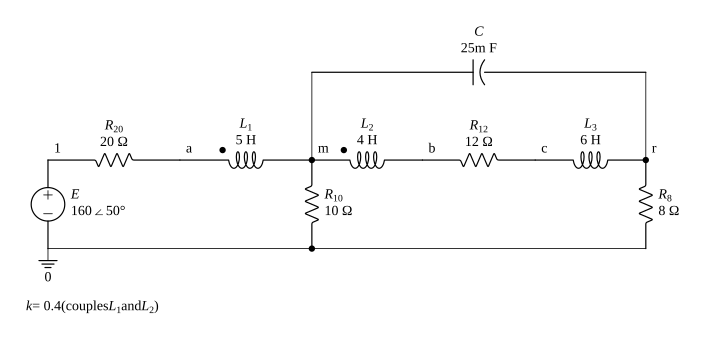

In [19]:
c7 = '''
e,1,0,(160∠50°)
r20,1,a,20
l1,a,m,5
l2,m,b,4
m,l1,l2,k=0.4
r12,b,c,12
l3,c,r,6
c,m,r,25'm
r10,0,m,10
r8,r,0,8
'''
draw(c7)

In [20]:
r7 = ac(c7, omega=4)
r7.rounded(4)

Result(domain='ac')
  ap_e = -348.4
  ap_r10 = 73.70
  ap_r12 = 15.10
  ap_r20 = 243.5
  ap_r8 = 16.18
  i_c = 1.522 + 3.25*I
  i_e = -4.576 - 1.846*I
  i_l1 = 4.576 + 1.846*I
  i_l2 = -0.7856 - 1.378*I
  i_l3 = -0.7856 - 1.378*I
  i_r10 = -3.839 + 0.02518*I
  i_r12 = -0.7856 - 1.378*I
  i_r20 = 4.576 + 1.846*I
  i_r8 = 0.7367 + 1.871*I
  p_e = -348.4
  p_r10 = 73.70
  p_r12 = 15.10
  p_r20 = 243.5
  p_r8 = 16.18
  q_e = -185.5
  q_r10 = 0
  q_r12 = 0
  q_r20 = 0
  q_r8 = 0
  s_c = -64.39*I
  s_e = -348.4 - 185.5*I
  s_l1 = 17.38 + 221.5*I
  s_l2 = -17.38 - 1.829*I
  s_l3 = 30.21*I
  s_r10 = 73.70
  s_r12 = 15.10
  s_r20 = 243.5
  s_r8 = 16.18
  v_1 = 102.8 + 122.6*I
  v_a = 11.33 + 85.64*I
  v_b = 29.55 - 20.42*I
  v_c = 32.5 - 15.22*I
  v_e = 102.8 + 122.6*I
  v_l1 = -27.06 + 85.89*I
  v_l2 = 8.844 + 20.17*I
  v_l3 = 33.08 - 18.85*I
  v_m = 38.39 - 0.2518*I
  v_r = 5.893 + 14.97*I
  v_r10 = -38.39 + 0.2518*I
  v_r12 = -9.427 - 16.54*I
  v_r20 = 91.52 + 36.92*I
  v_r8 = 5.893 + 14.97*

In [21]:
{'ir8': polar(r7['ir8'])}

{'ir8': 2.011∠68.51°}

**The booklet prints**

$$i_{o} = i_{r8} = 2.011\angle{68.51^\circ}\ \mathrm{A}$$

## Sample 8 of 12: NR11's switched RLC with coupled coils

**A transient across a coupling**

*Course, Lesson 10 (Coupling)*

A 48 V source feeds a 10 mF capacitor, a 4 Ω resistor and a 0.8 H coil in series. A switch across the capacitor has been closed a long time and opens at t = 0. The coil is coupled, M = 0.8 H, to a 1.6 H coil across a 20 Ω resistor. Find $v_o$, the voltage across the 20 Ω, for t > 0.

![The circuit of NR11's switched RLC with coupled coils](https://learn.symbulator.com/assets/circuit/sym_nr11_coupled_capacitor.png)

**Why it is here.** A second-order primary talking to a first-order secondary through a mutual inductance. The answer carries both natural responses, an oscillation at 10 rad/s and a decay at 25 per second.

### DC, t < 0

*Analysis: DC.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=10&entry=17)

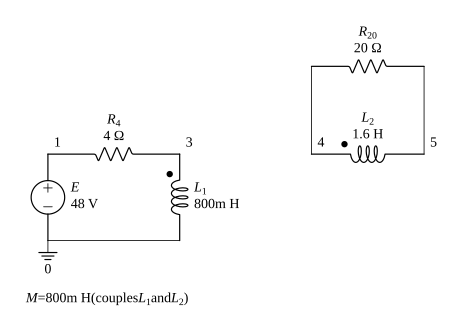

In [22]:
c8 = '''
e,1,0,48
r4,1,3,4
l1,3,0,0.8
l2,4,5,1.6
r20,4,5,20
m,l1,l2,0.8
'''
draw(c8)

In [23]:
r8 = dc(c8)
r8

Result(domain='dc')
  i_e = -12
  i_l1 = 12
  i_l2 = 0
  i_r20 = 0
  i_r4 = 12
  p_e = -576
  p_l1 = 0
  p_l2 = 0
  p_r20 = 0
  p_r4 = 576
  r_e = 4
  v_1 = 48
  v_3 = 0
  v_4 = 0
  v_5 = 0
  v_e = 48
  v_l1 = 0
  v_l2 = 0
  v_r20 = 0
  v_r4 = 48
  note: Node(s) 5, 4 have no path to node 0 (they lie behind a port or a coupling), so their voltages are measured against 5, taken as 0.

**The booklet prints**

$$i_{l1} = 12\ \mathrm{A}$$

$$i_{l2} = 0\ \mathrm{A}$$

### TR, t > 0

*Analysis: TR. Rounding: 4 digits. Evaluate: v4-v5.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=10&entry=18)

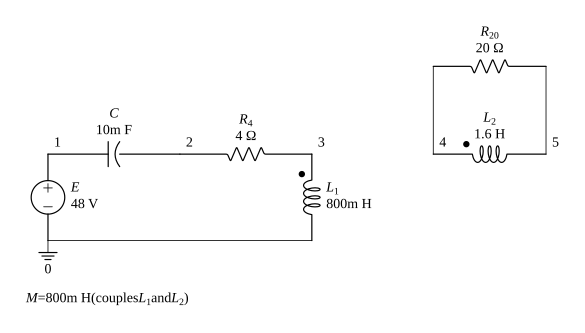

In [24]:
c9 = '''
e,1,0,48
c,1,2,10'm,0
r4,2,3,4
l1,3,0,0.8,12
l2,4,5,1.6,0
r20,4,5,20
m,l1,l2,0.8
'''
draw(c9)

In [25]:
r9 = tr(c9, variables=['v_4', 'v_5', 'i_l1'])
r9.rounded(4)

Result(domain='tr')
  i_l1 = -3.0*exp(-25.0*t) + 15.0*exp(-5.0*t)*cos(10.0*t)
  v_4 = ((-120.0*sin(10.0*t) + 60.0*cos(10.0*t))*exp(25.0*t) - 60.0*exp(5.0*t))*exp(-30.0*t)
  v_5 = 0
  note: Node(s) 5, 4 have no path to node 0 (they lie behind a port or a coupling), so their voltages are measured against 5, taken as 0.

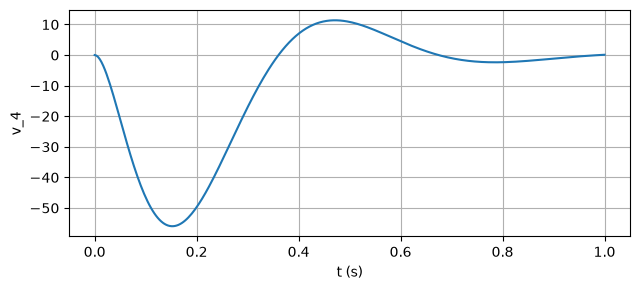

In [26]:
ts, ys = time_samples(c9, 'v_4', 1, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_4'); plt.grid(True); plt.tight_layout()

In [27]:
evaluate(r9, 'v4-v5')

((-120.0*sin(10.0*t) + 60.0*cos(10.0*t))*exp(25.0*t) - 60.0*exp(5.0*t))*exp(-30.0*t)

**The booklet prints**

$$v_{o} = e^{-5t}\left(60\cos 10t - 120\sin 10t\right) - 60\,e^{-25t}\ \mathrm{V}$$

## Sample 9 of 12: Bo2's Drill Exercise 6.6

**Two capacitors around an op amp**

*Course, Lesson 6 (Transients)*

In the circuit, suppose that $v_S(t) = 2 - 2u(t)$ V. Find $v_o(t)$ for t ≥ 0.

![The circuit of Bo2's Drill Exercise 6.6](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-6-op-amp-37.jpg)

**Why it is here.** An active second-order circuit whose two poles land in the same place. The repeated pole shows as the t in the answer, which no hand-picked solution form has to anticipate.

### DC, t < 0

*Analysis: DC.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=6d&entry=7)

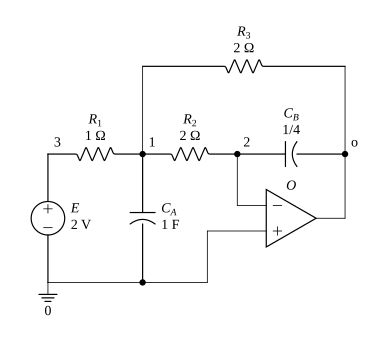

In [28]:
c10 = '''
e,3,0,2
r1,3,1,1
r2,1,2,2
r3,1,o,2
ca,1,0,1
cb,2,o,1/4
o,0,2,o
'''
draw(c10)

In [29]:
r10 = dc(c10)
r10

Result(domain='dc')
  i_ca = 0
  i_cb = 0
  i_e = -2
  i_o = -2
  i_r1 = 2
  i_r2 = 0
  i_r3 = 2
  p_ca = 0
  p_cb = 0
  p_e = -4
  p_o = -8
  p_r1 = 4
  p_r2 = 0
  p_r3 = 8
  r_e = 1
  v_1 = 0
  v_2 = 0
  v_3 = 2
  v_ca = 0
  v_cb = 4
  v_e = 2
  v_o = -4
  v_r1 = 2
  v_r2 = 0
  v_r3 = 4

**The booklet prints**

$$v_{ca} = 0\ \mathrm{V}$$

$$v_{cb} = 4\ \mathrm{V}$$

### TR, t > 0

*Analysis: TR.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=6d&entry=8)

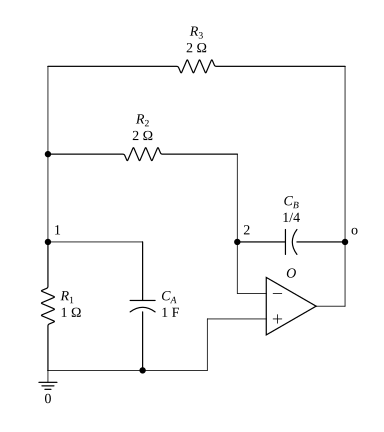

In [30]:
c11 = '''
r1,0,1,1
r2,1,2,2
r3,1,o,2
ca,1,0,1,0
cb,2,o,1/4,4
o,0,2,o
'''
draw(c11)

In [31]:
r11 = tr(c11)
r11

Result(domain='tr')
  i_ca = 2*(t - 1)*exp(-t)
  i_cb = -t*exp(-t)
  i_o = -2*exp(-t)
  i_r1 = 2*t*exp(-t)
  i_r2 = -t*exp(-t)
  i_r3 = (t + 2)*exp(-t)
  v_1 = -2*t*exp(-t)
  v_2 = 0
  v_o = 4*(-t - 1)*exp(-t)

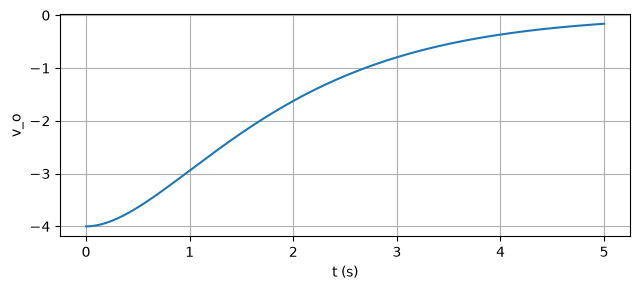

In [32]:
ts, ys = time_samples(c11, 'v_o', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

**The booklet prints**

$$v_{o} = (-4t-4)\,e^{-t}\ \mathrm{V}$$

## Sample 10 of 12: Prof. Boulet's exam problem

**The switch, the ladder and the damped sine**

*Course, Lesson 6 (Transients)*

The circuit comes from the circuits analysis class of Professor Eliane Boulet de Cabrera, at Universidad Tecnológica de Panamá. Find $v_1$ and $v$.

![The circuit of Prof. Boulet's exam problem](https://learn.symbulator.com/assets/practice/a-more-complex-problem-44.png)

**Why it is here.** Two capacitors with their own initial conditions, and after the switch a current source that is itself a damped sinusoid. The answer holds two natural modes and a forced response. The TI calculator took 78 seconds and version 9 takes about one.

### DC, t < 0

*Analysis: DC. Rounding: exact.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=6d&entry=18)

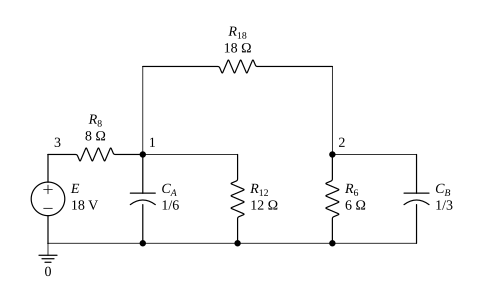

In [33]:
c12 = '''
e,3,0,18
r8,3,1,8
ca,1,0,1/6
r12,1,0,12
r18,1,2,18
r6,2,0,6
cb,2,0,1/3
'''
draw(c12)

In [34]:
r12 = dc(c12)
r12

Result(domain='dc')
  i_ca = 0
  i_cb = 0
  i_e = -9/8
  i_r12 = 3/4
  i_r18 = 3/8
  i_r6 = 3/8
  i_r8 = 9/8
  p_ca = 0
  p_cb = 0
  p_e = -81/4
  p_r12 = 27/4
  p_r18 = 81/32
  p_r6 = 27/32
  p_r8 = 81/8
  r_e = 16
  v_1 = 9
  v_2 = 9/4
  v_3 = 18
  v_ca = 9
  v_cb = 9/4
  v_e = 18
  v_r12 = 9
  v_r18 = 27/4
  v_r6 = 9/4
  v_r8 = 9

**The booklet prints**

$$v_{ca} = 9\ \mathrm{V}$$

$$v_{cb} = 9/4\ \mathrm{V}$$

### TR, t > 0

*Analysis: TR. Limit the results to v1, v2.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=6d&entry=19)

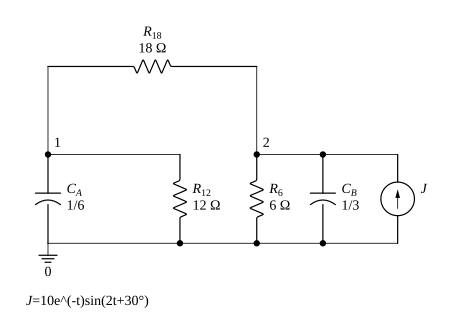

In [35]:
c13 = '''
ca,1,0,1/6,9
r12,1,0,12
r18,1,2,18
r6,2,0,6
cb,2,0,1/3,9/4
j,0,2,10e^(-t)*sin(2t+30*pi/180)
'''
draw(c13)

In [36]:
r13 = tr(c13, variables=['v_1', 'v_2'])
r13

Result(domain='tr')
  v_1 = ((-80*sin(2*t + pi/6) + 20*cos(2*t + pi/6) - 170*sqrt(3) + 153)*exp(t/2) + (193 + 160*sqrt(3))*exp(t))*exp(-3*t/2)/34
  v_2 = ((-160*sin(2*t + pi/6) - 980*cos(2*t + pi/6) - 153 + 170*sqrt(3))*exp(t/2) + 2*(193 + 160*sqrt(3))*exp(t))*exp(-3*t/2)/68

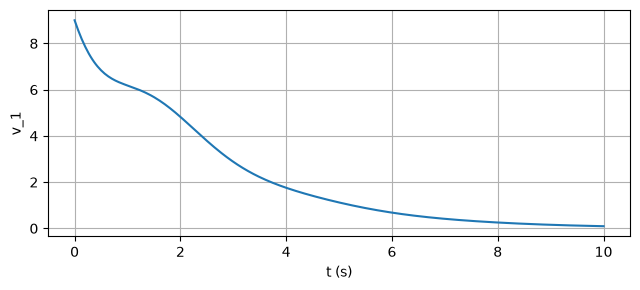

In [37]:
ts, ys = time_samples(c13, 'v_1', 10, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_1'); plt.grid(True); plt.tight_layout()

**The booklet prints**

$$\begin{aligned} v_{1} &= \left(\tfrac{5\sqrt{3}}{17}-\tfrac{20}{17}\right)e^{-t}\cos 2t - \left(\tfrac{20\sqrt{3}}{17}+\tfrac{5}{17}\right)e^{-t}\sin 2t \\ &\quad + \left(\tfrac{80\sqrt{3}}{17}+\tfrac{193}{34}\right)e^{-t/2} + \left(\tfrac{9}{2}-5\sqrt{3}\right)e^{-t}\ \mathrm{V}\end{aligned}$$

$$\begin{aligned} v_{2} &= -\left(\tfrac{245\sqrt{3}}{34}+\tfrac{20}{17}\right)e^{-t}\cos 2t + \left(\tfrac{245}{34}-\tfrac{20\sqrt{3}}{17}\right)e^{-t}\sin 2t \\ &\quad + \left(\tfrac{80\sqrt{3}}{17}+\tfrac{193}{34}\right)e^{-t/2} + \left(\tfrac{5\sqrt{3}}{2}-\tfrac{9}{4}\right)e^{-t}\ \mathrm{V}\end{aligned}$$

## Sample 11 of 12: AS7's Problem 19.2

**A two-port with no ground**

*Course, Lesson 13 (Two-Ports)*

Determine the impedance parameters of the ladder: four 1 Ω resistors in the upper rail, four in the lower, three 1 Ω rungs.

![The circuit of AS7's Problem 19.2](https://learn.symbulator.com/assets/circuit/as7-prob19-2.jpg)

**Why it is here.** Eleven resistors and no node 0 anywhere. Each port is written as its pair of terminals, so the lower rail stays in the circuit instead of being shorted to ground.

*Analysis: Find equivalent, Two-port parameters, z, between [a,f] and [e,j]. Rounding: 4 digits.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=13&entry=14)

In [38]:
c14 = '''
r1,a,b,1
r2,b,c,1
r3,c,d,1
r4,d,e,1
r5,f,g,1
r6,g,h,1
r7,h,i,1
r8,i,j,1
r9,b,g,1
r10,c,h,1
r11,d,i,1
'''

In [39]:
r14 = port(c14, '[a,f]', '[e,j]', 'z', domain='dc')
r14

PortResult('z', 11=41/15, 12=1/15, 21=1/15, 22=41/15)

**The booklet prints**

$$z_{11} = z_{22} = 41/15 = 2.733\ \Omega$$

$$z_{12} = z_{21} = 1/15 = 0.06667\ \Omega$$

## Sample 12 of 12: NR12's Example 18.6

**Two amplifiers known only by their h parameters**

*Nilsson & Riedel sampler*

Two identical amplifiers are connected in cascade. Each is described by its h parameters: $h_{11}$ = 1000 Ω, $h_{12}$ = 0.0015, $h_{21}$ = 100, $h_{22}$ = 100 µS. The source has 500 Ω of internal resistance and the load is 10 kΩ. Find the voltage gain $V_2/V_g$.

![The circuit of NR12's Example 18.6](https://learn.symbulator.com/assets/circuit/nr12-ex18-6.jpg)

**Why it is here.** Each amplifier is a single element carrying its four parameters, and the cascade is two lines sharing a node. No matrix products, no conversions between parameter sets.

*Analysis: DC. Rounding: approx. Evaluate: v_c/vg.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=nr12&entry=16)

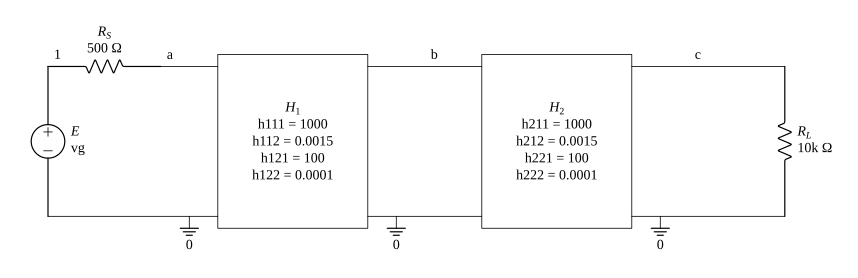

In [40]:
c15 = '''
e,1,0,vg
rs,1,a,500
h1,a,b,[1000,0.0015,100,0.0001]
h2,b,c,[1000,0.0015,100,0.0001]
rl,c,0,10'k
'''
draw(c15)

In [41]:
r15 = dc(c15)
r15

Result(domain='dc')
  i_e = -0.000683333333333333*vg
  i_h1a = 0.000683333333333333*vg
  i_h1b = 0.0666666666666667*vg
  i_h2b = -0.0666666666666667*vg
  i_h2c = -3.33333333333333*vg
  i_rl = 3.33333333333333*vg
  i_rs = 0.000683333333333333*vg
  p_e = -0.000683333333333333*vg**2
  p_rl = 111111.111111111*vg**2
  p_rs = 0.000233472222222222*vg**2
  r_e = 1463.41463414634
  v_1 = vg
  v_a = 0.658333333333333*vg
  v_b = -16.6666666666667*vg
  v_c = 33333.3333333333*vg
  v_e = vg
  v_rl = 33333.3333333333*vg
  v_rs = 0.341666666666667*vg

In [42]:
evaluate(r15, 'v_c/vg')

33333.3333333333

**The booklet prints**

$$V_{2}/V_{g} = v_{c}/v_{g} = 33333.33$$

## Bonus: A freebie, on the house

**One dependent source of each kind**

*Course, Lesson 3 (Sources), as the Showing-off Problem*

Find positive values for $V_s$ and $I_s$ that will result in 80 W delivered by the VCCS and 0 W dissipated in the CCVS.

![The circuit of A freebie, on the house](https://learn.symbulator.com/assets/practice/the-showing-off-problem-expert-4.png)

**Why it is here.** Invented by Roberto Perez-Franco in 2013 to show off. A VCCS, a CCVS, a CCCS and a VCVS woven through seven resistors, and the question runs backwards, from powers to sources. The two power conditions are quadratic, so four solutions fit, and the conditions pick the positive one. The answers also show why the CCVS dissipates nothing: its controlling current is exactly zero.

*Analysis: DC. Rounding: 4 digits. Expert Mode: equations pjd1 = -80 and ped2 = 0, unknowns vs, is, conditions vs > 0 and is > 0.*

[Open this run in the app](https://symbulator.pythonanywhere.com/?lesson=3&entry=49)

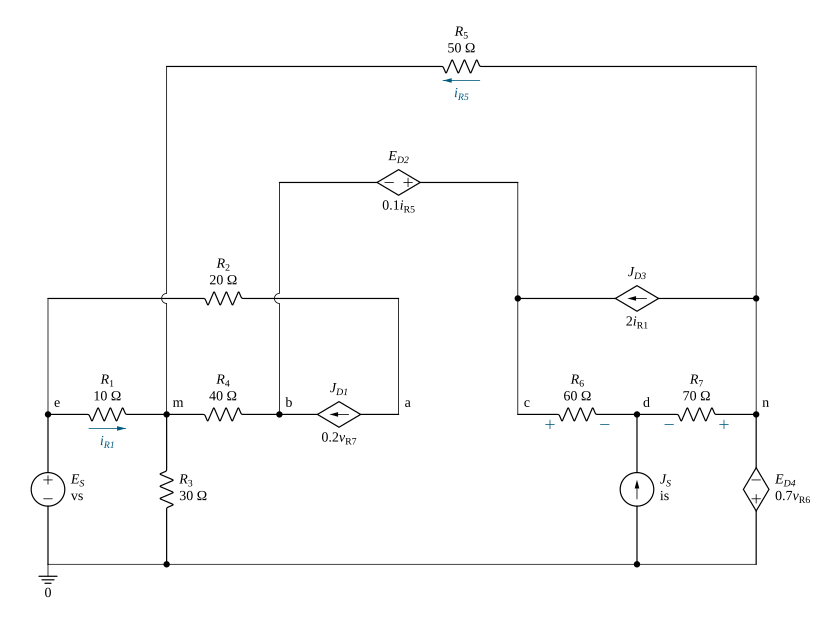

In [43]:
c16 = '''
es,e,0,vs
js,0,d,is
r1,e,m,10
r2,a,e,20
r3,m,0,30
r4,b,m,40
r5,n,m,50
r6,c,d,60
r7,n,d,70
jd1,a,b,0.2vr7
ed2,c,b,0.1ir5
jd3,n,c,2ir1
ed4,0,n,0.7vr6
'''
draw(c16)

In [44]:
r16 = dc(c16, equations=['p_jd1 = -80', 'p_ed2 = 0'], unknowns=['vs', 'is'], conditions=['vs > 0', 'is > 0'])
r16.rounded(4)

Result(domain='dc')
  i_ed2 = 1.469
  i_ed4 = 1.071
  i_es = 1.080
  i_jd1 = -1.676
  i_jd3 = 1.191
  i_js = 0.3973
  i_r1 = 0.5955
  i_r2 = 1.676
  i_r3 = 0.3886
  i_r4 = -0.2069
  i_r5 = 0
  i_r6 = -0.2776
  i_r7 = -0.1197
  is = 0.3973
  p_ed2 = 0
  p_ed4 = -12.49
  p_es = 19.02
  p_jd1 = -80.00
  p_jd3 = 9.859
  p_js = -7.960
  p_r1 = 3.547
  p_r2 = 56.15
  p_r3 = 4.531
  p_r4 = 1.713
  p_r5 = 0
  p_r6 = 4.623
  p_r7 = 1.003
  r_ed2 = 0
  r_ed4 = 10.88
  r_es = -16.31
  r_jd1 = 28.49
  r_jd3 = -6.949
  r_js = 50.44
  v_a = 51.13
  v_b = 3.381
  v_c = 3.381
  v_d = 20.04
  v_e = 17.61
  v_ed2 = 0
  v_ed4 = -11.66
  v_es = 17.61
  v_jd1 = 47.74
  v_jd3 = 8.277
  v_js = -20.04
  v_m = 11.66
  v_n = 11.66
  v_r1 = 5.955
  v_r2 = 33.51
  v_r3 = 11.66
  v_r4 = -8.277
  v_r5 = 0
  v_r6 = -16.65
  v_r7 = -8.378
  vs = 17.61

**The booklet prints**

$$v_{s} = 17.61\ \mathrm{V}$$

$$i_{s} = 0.3973\ \mathrm{A}$$

$$i_{r5} = 0\ \mathrm{A}$$

## Where next

* The booklet: https://learn.symbulator.com/dozen.pdf
* Every run above opens in the app: https://symbulator.pythonanywhere.com/
* The rest of the built-in examples as notebooks, one per book, are beside this file.